In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pickle

In [ ]:
df = pd.read_csv("churn_logistic.csv")

df.head()

,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


In [ ]:
df.drop(['State','Phone'], axis=1, inplace=True)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(x_train, y_train)

y_pred_log = log_reg.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_log))

print(confusion_matrix(y_test,y_pred_log))

print(classification_report(y_test,y_pred_log))

Logistic Regression Accuracy:
0.7789473684210526
[[449 136]
 [116 439]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       585
           1       0.76      0.79      0.78       555

    accuracy                           0.78      1140
   macro avg       0.78      0.78      0.78      1140
weighted avg       0.78      0.78      0.78      1140



**Observed unusually high accuracy due to leakage columns:
Day Charge, Eve Charge, Night Charge, Intl Charge.

These columns are derived from minutes and must be removed.**

In [ ]:
df.drop([
'Day Charge',
'Eve Charge',
'Night Charge',
'Intl Charge',
'Area Code'
], axis=1, inplace=True)

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [ ]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test,y_pred_rf))

print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy:
0.9403508771929825
[[559  26]
 [ 42 513]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       585
           1       0.95      0.92      0.94       555

    accuracy                           0.94      1140
   macro avg       0.94      0.94      0.94      1140
weighted avg       0.94      0.94      0.94      1140



In [ ]:
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = feature_importances.sort_values(
    ascending=False
).head(10)

print(top_features)

Day Mins          0.281053
CustServ Calls    0.185320
Intl Plan         0.115786
Eve Mins          0.085793
Intl Mins         0.056826
Night Mins        0.048076
Intl Calls        0.043335
Day Calls         0.035243
Account Length    0.034379
Night Calls       0.031351
dtype: float64


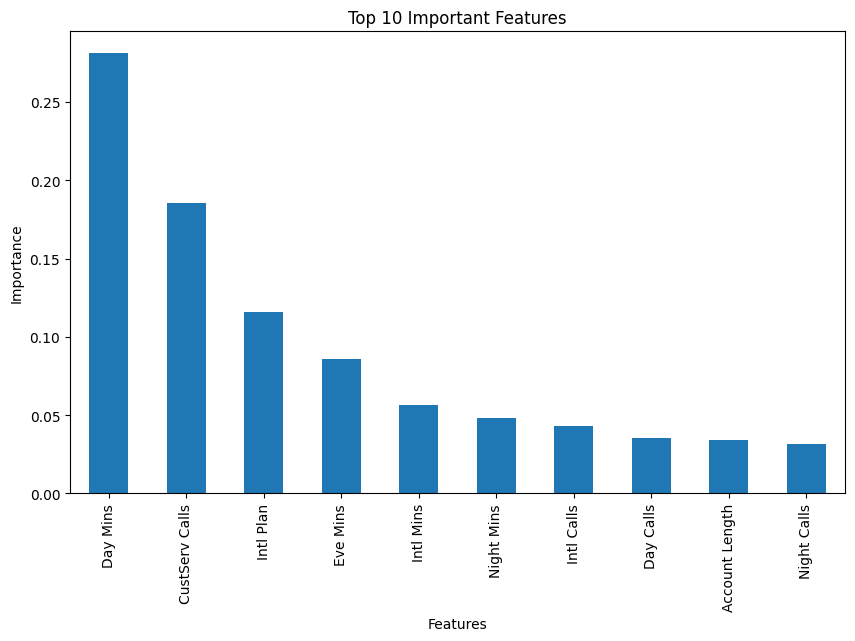

In [ ]:
plt.figure(figsize=(10,6))

top_features.plot(kind="bar")

plt.title("Top 10 Important Features")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [ ]:
pickle.dump(rf, open("churn_rf_model.pkl","wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
# Save feature names (VERY IMPORTANT)

feature_columns = X.columns

pickle.dump(feature_columns, open("feature_columns.pkl","wb"))